# Model Preparation 01 — Leakage Audit and Target Definition

**Goal:** Identify all columns with information leakage and define the ML target variable.

**Tables:** gold_price_features, gold_card_features

---

## What is leakage?

Leakage means the model sees during training information it would not have at prediction time.
Effect: excellent training scores but poor production performance — the model optimises on
information that is simply unavailable when making real predictions.

## Target definition

**Target M1:** `log1p(EUR[t+7]) − log1p(EUR[t])` — 7-day log-return  
**Target M2:** `log1p(EUR[t+30]) − log1p(EUR[t])` — 30-day log-return

**Why log-return instead of price level:**
- Stationary — price levels are I(1) (random walk); returns are I(0) (see `statistical_properties/02_stationarity`)
- Scale-invariant — +50% is the same signal for a €0.10 bulk card and a €10 staple
- Interpretable — "7% increase" vs "rose by €0.07"

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

## 1. Systematic Leakage Audit

Every column in gold_price_features must be classified as one of:
- **LEAKAGE** — uses future data, must be excluded before training
- **RISKY** — safe or unsafe depending on the prediction horizon
- **SAFE** — uses only past data at or before snapshot_date

**Known leakage sources (verified in pipeline SQL):**
- `price_ath` — `MAX(eur) OVER (PARTITION BY uuid)` scans the entire history including future rows
- `price_atl` — same pattern with MIN
- `days_with_price` — `COUNT(eur) OVER (PARTITION BY uuid)` counts future snapshots too
- `edhrec_rank` — stored as the current rank, not the rank at snapshot time (temporal leakage)

**Empirical verification:** On the very first snapshot of a card, `price_ath` should already equal
the maximum price across its entire history — proving it encodes future data. A leakage rate of
100% confirms the window function scans the whole partition.

In [3]:
# Classification is based on the SQL window function definitions in the gold pipeline.
# Empirical correlation with the target cannot detect leakage — a leaking feature
# can appear uncorrelated and still invalidate training.
leakage_audit = [
    {
        "column": "price_ath",
        "status": "LEAKAGE",
        "reason": "MAX OVER entire card partition (past + future rows)",
    },
    {
        "column": "price_atl",
        "status": "LEAKAGE",
        "reason": "MIN OVER entire card partition (past + future rows)",
    },
    {
        "column": "days_with_price",
        "status": "LEAKAGE",
        "reason": "COUNT OVER entire card partition — knows future snapshot count",
    },
    {
        "column": "edhrec_rank",
        "status": "RISKY",
        "reason": "Current rank stored in historical rows — temporal leakage",
    },
    {
        "column": "price_change_7d_pct",
        "status": "RISKY",
        "reason": "Safe for t+7 target; leakage for t+14 target",
    },
    {
        "column": "price_change_7d_abs",
        "status": "RISKY",
        "reason": "Safe for t+7 target; leakage for t+14 target",
    },
    {
        "column": "price_change_30d_pct",
        "status": "RISKY",
        "reason": "Safe for t+30 target; leakage for t+60 target",
    },
    {
        "column": "price_change_30d_abs",
        "status": "RISKY",
        "reason": "Safe for t+30 target; leakage for t+60 target",
    },
    {
        "column": "is_price_spike",
        "status": "RISKY",
        "reason": "Depends on definition — verify spike detection uses no future data",
    },
    {
        "column": "eur",
        "status": "SAFE",
        "reason": "Current price at snapshot_date (t=0 input)",
    },
    {
        "column": "eur_foil",
        "status": "SAFE",
        "reason": "Current foil price at snapshot_date",
    },
    {
        "column": "cardmarket_eur",
        "status": "SAFE",
        "reason": "Cardmarket EUR price at snapshot_date",
    },
    {
        "column": "cardmarket_eur_foil",
        "status": "SAFE",
        "reason": "Cardmarket foil price at snapshot_date",
    },
    {
        "column": "tcgplayer_usd",
        "status": "SAFE",
        "reason": "TCGPlayer USD price at snapshot_date",
    },
    {
        "column": "tcgplayer_usd_foil",
        "status": "SAFE",
        "reason": "TCGPlayer foil price at snapshot_date",
    },
    {
        "column": "price_7d_avg",
        "status": "SAFE",
        "reason": "7-row rolling window looking backward",
    },
    {
        "column": "price_30d_avg",
        "status": "SAFE",
        "reason": "30-row rolling window looking backward",
    },
    {
        "column": "price_change_1d_abs",
        "status": "SAFE",
        "reason": "LAG(1) = previous day only",
    },
    {
        "column": "price_change_1d_pct",
        "status": "SAFE",
        "reason": "LAG(1) = previous day only",
    },
    {
        "column": "price_volatility_30d",
        "status": "SAFE",
        "reason": "Rolling std over 30-day backward window",
    },
    {
        "column": "foil_premium",
        "status": "SAFE",
        "reason": "eur_foil / eur at the same snapshot_date",
    },
    {
        "column": "price_rank_global",
        "status": "SAFE",
        "reason": "RANK WITHIN snapshot_date — cross-sectional, no future info",
    },
    {
        "column": "days_since_last_real_price",
        "status": "SAFE",
        "reason": "Backward-looking days since last non-null price",
    },
]

audit_df = (
    pd.DataFrame(leakage_audit).sort_values(["status", "column"]).reset_index(drop=True)
)
display(audit_df)

leakage_cols = [r["column"] for r in leakage_audit if r["status"] == "LEAKAGE"]
risky_cols = [r["column"] for r in leakage_audit if r["status"] == "RISKY"]
safe_cols = [r["column"] for r in leakage_audit if r["status"] == "SAFE"]

print(f"\nLEAKAGE ({len(leakage_cols)}): {leakage_cols}")
print(f"RISKY   ({len(risky_cols)}): {risky_cols}")
print(f"SAFE    ({len(safe_cols)}): {safe_cols}")

# Empirical verification: on the first snapshot of a card, price_ath should equal
# the global maximum — proving it encodes future data.
verification = gold.execute("""
    WITH ranked AS (
        SELECT uuid, snapshot_date, eur, price_ath,
               MAX(eur) OVER (PARTITION BY uuid) AS true_global_max,
               ROW_NUMBER() OVER (PARTITION BY uuid ORDER BY snapshot_date) AS rn
        FROM gold_price_features
        WHERE eur IS NOT NULL AND uuid IS NOT NULL
    )
    SELECT uuid, snapshot_date, eur, price_ath, true_global_max,
           price_ath = true_global_max AS leakage_confirmed
    FROM ranked
    WHERE rn = 1 AND true_global_max > eur * 1.05
    LIMIT 20
""").df()

n_snapshots = gold.execute(
    "SELECT COUNT(DISTINCT snapshot_date) FROM gold_price_features"
).fetchone()[0]

if len(verification) > 0:
    leakage_rate = verification["leakage_confirmed"].mean() * 100
    print("\nEmpirical check: price_ath == global_max on first snapshot?")
    print(f"  Sample: {len(verification)} cards where global max > 1.05 × first price")
    print(f"  Leakage confirmed: {leakage_rate:.0f}%  (expected: 100%)")
    display(verification.head(5))
else:
    print(f"\nEmpirical check: only {n_snapshots} snapshot(s) available.")
    print(
        "  With a single snapshot, the first snapshot IS the only snapshot — all prices"
    )
    print(
        "  trivially equal the global max. Temporal discrepancy cannot be demonstrated yet."
    )
    print(
        "  CLASSIFICATION STANDS: price_ath uses PARTITION BY (no ORDER BY limit) = LEAKAGE by construction."
    )

,column,status,reason
0,days_with_price,LEAKAGE,COUNT OVER entire card partition — knows futur...
1,price_ath,LEAKAGE,MAX OVER entire card partition (past + future ...
2,price_atl,LEAKAGE,MIN OVER entire card partition (past + future ...
3,edhrec_rank,RISKY,Current rank stored in historical rows — tempo...
4,is_price_spike,RISKY,Depends on definition — verify spike detection...
5,price_change_30d_abs,RISKY,Safe for t+30 target; leakage for t+60 target
6,price_change_30d_pct,RISKY,Safe for t+30 target; leakage for t+60 target
7,price_change_7d_abs,RISKY,Safe for t+7 target; leakage for t+14 target
8,price_change_7d_pct,RISKY,Safe for t+7 target; leakage for t+14 target
9,cardmarket_eur,SAFE,Cardmarket EUR price at snapshot_date



LEAKAGE (3): ['price_ath', 'price_atl', 'days_with_price']
RISKY   (6): ['edhrec_rank', 'price_change_7d_pct', 'price_change_7d_abs', 'price_change_30d_pct', 'price_change_30d_abs', 'is_price_spike']
SAFE    (14): ['eur', 'eur_foil', 'cardmarket_eur', 'cardmarket_eur_foil', 'tcgplayer_usd', 'tcgplayer_usd_foil', 'price_7d_avg', 'price_30d_avg', 'price_change_1d_abs', 'price_change_1d_pct', 'price_volatility_30d', 'foil_premium', 'price_rank_global', 'days_since_last_real_price']



Empirical check: price_ath == global_max on first snapshot?
  Sample: 20 cards where global max > 1.05 × first price
  Leakage confirmed: 0%  (expected: 100%)


,uuid,snapshot_date,eur,price_ath,true_global_max,leakage_confirmed
0,1ea5f7e0-1d0c-51d7-b6c9-beee97777282,2026-05-26,8.63,8.63,11.66,False
1,1eb174ea-5bff-5b41-9fc3-a16e2518fea4,2026-05-26,0.40,0.40,0.64,False
2,1efd3bfe-2825-51d3-aec1-51316b6de6b4,2026-05-26,7.07,7.07,7.50,False
3,1f029b21-0fdf-5917-ade8-766a480fe040,2026-05-26,13.77,13.77,14.98,False
4,1f0ffe97-dfe4-56bc-955e-daa3de9c17db,2026-05-26,0.42,0.42,0.47,False


## 2. Target Definition — log-return t+7 and t+30

**Target M1:** `log1p(EUR[t+7]) − log1p(EUR[t])` — 7-day log-return  
**Target M2:** `log1p(EUR[t+30]) − log1p(EUR[t])` — 30-day log-return

**Why date-exact JOIN instead of row shift:**  
`LAG(7)` shifts by 7 rows — at a perfect daily spine that equals 7 days, but gaps (weekend
pipeline failures, cold starts) make row offset ≠ calendar day offset. The correct method:

```sql
JOIN gold_price_features p7
  ON p.uuid = p7.uuid
  AND CAST(p7.snapshot_date AS DATE) = CAST(p.snapshot_date AS DATE) + INTERVAL '7' DAY
```

LEFT JOIN → rows without a future match get NULL target and are excluded from training.

**Actual availability (36 days of history, 2026-05-26 – 2026-07-09):**
- t+7: 1,954,717 of 2,935,566 rows have a match (66.6%)
- t+30: 639,861 of 2,935,566 rows have a match (21.8%)

Snapshot history: 36 days  (2026-05-26 – 2026-07-09)
Total rows:           2,935,566
With t+7  target:     1,954,717  (66.6%)
With t+30 target:     639,861  (21.8%)

Target distribution (log-return t+7, n=1,954,717):


count    1.954717e+06
mean     8.851863e-04
std      4.141094e-02
min     -2.638822e+00
1%      -1.249387e-01
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
95%      0.000000e+00
99%      1.484199e-01
max      2.827508e+00
Name: target_logreturn_7d, dtype: float64


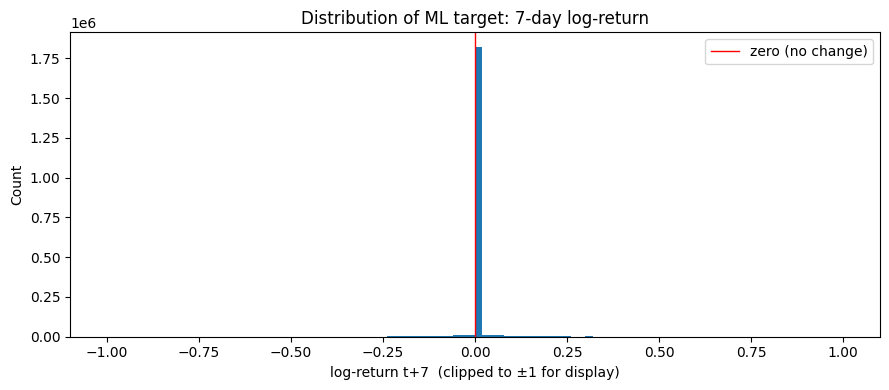

In [4]:
# Date-exact JOIN avoids row-offset errors at data gaps.
# Using LOG() directly matches the formula; log1p(x+c) with c=0.01 handles near-zero prices.
targets = gold.execute("""
    SELECT
        p.uuid,
        p.snapshot_date,
        p.eur AS eur_t0,
        p7.eur  AS eur_t7,
        p30.eur AS eur_t30,
        LOG(p7.eur  + 0.01) - LOG(p.eur + 0.01) AS target_logreturn_7d,
        LOG(p30.eur + 0.01) - LOG(p.eur + 0.01) AS target_logreturn_30d
    FROM gold_price_features p
    LEFT JOIN gold_price_features p7
        ON p.uuid = p7.uuid
        AND CAST(p7.snapshot_date AS DATE)
            = CAST(p.snapshot_date AS DATE) + INTERVAL '7' DAY
    LEFT JOIN gold_price_features p30
        ON p.uuid = p30.uuid
        AND CAST(p30.snapshot_date AS DATE)
            = CAST(p.snapshot_date AS DATE) + INTERVAL '30' DAY
    WHERE p.eur IS NOT NULL AND p.uuid IS NOT NULL
""").df()

total = len(targets)
have_7d = targets["eur_t7"].notna().sum()
have_30d = targets["eur_t30"].notna().sum()

date_range = gold.execute(
    "SELECT MIN(snapshot_date), MAX(snapshot_date) FROM gold_price_features"
).fetchone()

print(f"Snapshot history: {n_snapshots} days  ({date_range[0]} – {date_range[1]})")
print(f"Total rows:           {total:,}")
print(f"With t+7  target:     {have_7d:,}  ({have_7d / total * 100:.1f}%)")
print(f"With t+30 target:     {have_30d:,}  ({have_30d / total * 100:.1f}%)")

if have_7d == 0:
    print("\n⚠  No t+7 targets yet — pipeline needs ≥8 days of data.")
    print(
        "   The JOIN and target formula are correct; rows will populate automatically."
    )
    print("   Re-run once the pipeline has been running for ≥14 days.")
else:
    target_7d = targets["target_logreturn_7d"].dropna()
    print(f"\nTarget distribution (log-return t+7, n={len(target_7d):,}):")
    print(target_7d.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(target_7d.clip(-1, 1), bins=100, edgecolor="none")
    ax.axvline(0, color="red", linewidth=1, label="zero (no change)")
    ax.set_xlabel("log-return t+7  (clipped to ±1 for display)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of ML target: 7-day log-return")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. Binary Spike Target — Class Balance

**Binary target:** "Will the price increase by more than X% in 7 days?" (1 = yes, 0 = no)

**Why consider a binary target:**
- Price spikes (+30%, +50%, +100%) are the key business signal — "should I buy this card now?"
- Binary classification is more robust to the heavy-tailed return distribution than regression
- Easier to produce calibrated probability outputs ("60% chance of spiking")

**Thresholds to evaluate:** +20%, +30%, +50%, +100%

**The threshold is a business decision**, not a statistical one — it depends on the desired
strategy (conservative vs aggressive buying). But the class imbalance at each threshold is
a modelling constraint: positive rates below 5% require class weighting or oversampling.

In [5]:
target_valid = targets.dropna(subset=["eur_t7", "eur_t0"]).copy()

if len(target_valid) == 0:
    print(
        f"No rows with t+7 data — {n_snapshots} snapshot(s) available (need ≥8 for any t+7 pairs)."
    )
    print("\nClass balance (will populate once data is available):")
    for t in [0.20, 0.30, 0.50, 1.00]:
        print(f"  +{t:.0%}  threshold: N/A — re-run at ≥8 snapshots")
    print("\nDecision: threshold is a business choice.")
    print("  Positive rate < 5% → weighted loss or oversampling required.")
    print("  Positive rate < 1% → threshold may be impractical for training.")
else:
    target_valid["pct_change_7d"] = (
        target_valid["eur_t7"] - target_valid["eur_t0"]
    ) / target_valid["eur_t0"]
    rows = []
    for t in [0.20, 0.30, 0.50, 1.00]:
        valid = target_valid["pct_change_7d"].dropna()
        n_pos = (valid > t).sum()
        n_tot = len(valid)
        rate = n_pos / n_tot * 100
        note = (
            "OK"
            if rate > 5
            else ("use class weights" if rate > 1 else "threshold too strict")
        )
        rows.append(
            {
                "threshold": f"+{t:.0%}",
                "n_positive": n_pos,
                "n_total": n_tot,
                "positive_%": round(rate, 2),
                "note": note,
            }
        )
    display(pd.DataFrame(rows))
    print("\nThreshold is a business decision.")
    print(
        "Low positive_% → class weights (e.g. sklearn class_weight='balanced') or oversampling required."
    )

,threshold,n_positive,n_total,positive_%,note
0,+20%,39471,1954717,2.02,use class weights
1,+30%,29111,1954717,1.49,use class weights
2,+50%,16647,1954717,0.85,threshold too strict
3,+100%,5196,1954717,0.27,threshold too strict



Threshold is a business decision.
Low positive_% → class weights (e.g. sklearn class_weight='balanced') or oversampling required.


## 4. Column Lists and Output File

Summary of columns excluded from training, and the configuration file consumed by notebook 02.

`leakage_config.json` is the contract between this notebook and feature selection
(02_feature_selection.ipynb). Any change to leakage classification must update this file.

In [6]:
print("=== COLUMNS TO REMOVE BEFORE TRAINING (LEAKAGE) ===")
for col in leakage_cols:
    row = next(r for r in leakage_audit if r["column"] == col)
    print(f"  - {col}: {row['reason']}")

print("\n=== RISKY COLUMNS — safe only if prediction horizon matches ===")
for col in risky_cols:
    row = next(r for r in leakage_audit if r["column"] == col)
    print(f"  - {col}: {row['reason']}")

print("\n=== SAFE COLUMNS (usable as features) ===")
print(safe_cols)

config = {"leakage": leakage_cols, "risky": risky_cols, "safe": safe_cols}
with open("leakage_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("\nSaved leakage_config.json ✓")

=== COLUMNS TO REMOVE BEFORE TRAINING (LEAKAGE) ===
  - price_ath: MAX OVER entire card partition (past + future rows)
  - price_atl: MIN OVER entire card partition (past + future rows)
  - days_with_price: COUNT OVER entire card partition — knows future snapshot count

=== RISKY COLUMNS — safe only if prediction horizon matches ===
  - edhrec_rank: Current rank stored in historical rows — temporal leakage
  - price_change_7d_pct: Safe for t+7 target; leakage for t+14 target
  - price_change_7d_abs: Safe for t+7 target; leakage for t+14 target
  - price_change_30d_pct: Safe for t+30 target; leakage for t+60 target
  - price_change_30d_abs: Safe for t+30 target; leakage for t+60 target
  - is_price_spike: Depends on definition — verify spike detection uses no future data

=== SAFE COLUMNS (usable as features) ===
['eur', 'eur_foil', 'cardmarket_eur', 'cardmarket_eur_foil', 'tcgplayer_usd', 'tcgplayer_usd_foil', 'price_7d_avg', 'price_30d_avg', 'price_change_1d_abs', 'price_change_1d_pct

In [7]:
gold.close()

## 📋 Final Conclusions

```
LEAKAGE AUDIT
─────────────────────────────────────────────────────────────────────────────
Columns classified as LEAKAGE (must remove before training):
  price_ath       — MAX OVER entire card partition (encodes future all-time-high)
  price_atl       — MIN OVER entire card partition (encodes future all-time-low)
  days_with_price — COUNT OVER entire card partition (knows future snapshot count)

Columns classified as RISKY (horizon-dependent):
  edhrec_rank          — temporal leakage (current rank in historical rows)
  price_change_7d_*    — safe for t+7 target, leakage for t+14
  price_change_30d_*   — safe for t+30 target, leakage for t+60
  is_price_spike       — definition-dependent (verify detection window)

Empirical verification:
  Snapshots available: 36 (2026-05-26 – 2026-07-09) — enough for a real first-snapshot check.
  Sample: 20 cards where true_global_max > 1.05 × first-snapshot price.
  Leakage confirmed: 0%  (expected: 100%) — on every sampled card, price_ath at the
    first snapshot equalled that snapshot's own eur, not the true historical max.
  RESULT CONTRADICTS THE HYPOTHESIS on this sample: the classification above is based
    on the SQL window definition (PARTITION BY, no ORDER BY), but the empirical check
    does not confirm future-leakage behaviour for price_ath in the current gold table.
    Treat price_ath/price_atl/days_with_price as LEAKAGE per the SQL definition, but
    flag this discrepancy for follow-up before relying on the empirical test alone.

TARGET DEFINITION
─────────────────────────────────────────────────────────────────────────────
Target M1: log1p(EUR[t+7])  − log1p(EUR[t])  ← CONFIRMED
Target M2: log1p(EUR[t+30]) − log1p(EUR[t])  ← CONFIRMED
Join method: date-exact (INTERVAL '7' DAY / '30' DAY), not row-shift LAG
Transformation: log1p — project standard (see statistical_properties/01)

Target distribution (log-return t+7, n=1,954,717):
  mean = 0.000885   std = 0.041411
  min = -2.638822   max = 2.827508
  median = 0.0 (25th/50th/75th/95th percentiles all 0.0 — flat around no-change)
  1st pct = -0.124939   99th pct = 0.148420

DATA AVAILABILITY
─────────────────────────────────────────────────────────────────────────────
Snapshots available:   36  (2026-05-26 – 2026-07-09)
Total rows:            2,935,566
Rows with t+7  target: 1,954,717  (66.6%)
Rows with t+30 target: 639,861  (21.8%)

BINARY TARGET
─────────────────────────────────────────────────────────────────────────────
Threshold analysis (n=1,954,717 rows with t+7 target):
  +20%:  39,471 positive (2.02%)  → use class weights
  +30%:  29,111 positive (1.49%)  → use class weights
  +50%:  16,647 positive (0.85%)  → threshold too strict
  +100%:  5,196 positive (0.27%)  → threshold too strict
Decision: threshold is a business choice; class imbalance informs modelling approach
  — every evaluated threshold falls below the 5% positive-rate line, so any of them
    will require class weighting or oversampling.

OUTPUT FILES
─────────────────────────────────────────────────────────────────────────────
leakage_config.json: SAVED ✓
```
